Saving poisson-output.zip to poisson-output (1).zip
Saving gaussian-output.zip to gaussian-output (1).zip
Saving speckle-output.zip to speckle-output (1).zip
Archive:  speckle-output.zip
   creating: content/speckle-output-new/
  inflating: content/speckle-output-new/Chip8_IgG_FC_3-14_R1_speckle_01_sigma_0.050.png  
  inflating: content/speckle-output-new/Chip8_IgG_FC_8-14_R1_speckle_06_sigma_0.189.png  
  inflating: content/speckle-output-new/slide5_350_8-14_R1_speckle_06_sigma_0.189.png  
  inflating: content/speckle-output-new/Chip8_IgG_FC_4-14_R1_speckle_03_sigma_0.106.png  
  inflating: content/speckle-output-new/Chip7_IgG_HC_10-14_R1_speckle_06_sigma_0.189.png  
  inflating: content/speckle-output-new/Chip7_IgG_HC_12-14_R1_speckle_05_sigma_0.161.png  
  inflating: content/speckle-output-new/Chip8_IgG_FC_10-14_R1_speckle_06_sigma_0.189.png  
  inflating: content/speckle-output-new/slide5_350_10-14_R1_speckle_05_sigma_0.161.png  
  inflating: content/speckle-output-new/Chip7_IgG_HC

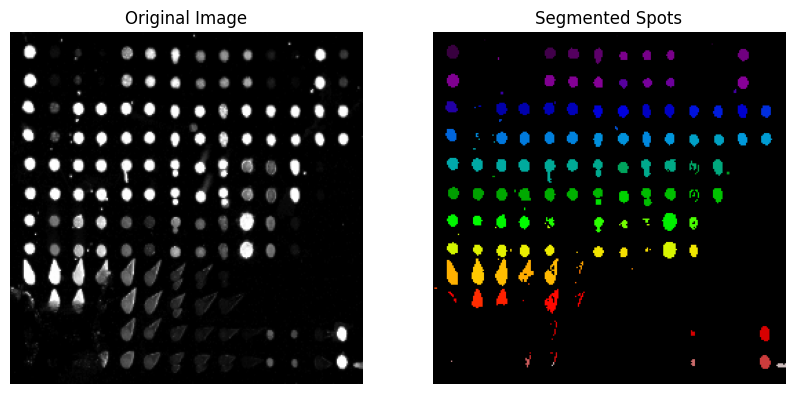

In [ ]:
# ==============================
# 1. Upload & unzip datasets
# ==============================
from google.colab import files
files.upload()

!unzip -o speckle-output.zip
!unzip -o gaussian-output.zip
!unzip -o poisson-output.zip

# ==============================
# 2. Imports
# ==============================
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256

# ==============================
# 3. Simple U-Net
# ==============================
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))

# ==============================
# 4. Dataset (auto mask)
# ==============================
class SpotDataset(Dataset):
    def __init__(self, img_paths):
        self.imgs = img_paths

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(self.imgs[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Cannot read image {self.imgs[idx]}")

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_norm = img / 255.0

        _, mask = cv2.threshold(
            img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        return (
            torch.tensor(img_norm).unsqueeze(0).float(),
            torch.tensor(mask).unsqueeze(0).float()
        )

# ==============================
# 5. Load training images (PNG + JPG)
# ==============================
TRAIN_FOLDERS = [
    "/content/content/speckle-output-new",
    "/content/gaussian-output-new",
    "/content/poisson-output-new"
]

train_imgs = []
for folder in TRAIN_FOLDERS:
    train_imgs.extend([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

train_imgs = sorted(train_imgs)
print("Total training images:", len(train_imgs))

loader = DataLoader(
    SpotDataset(train_imgs),
    batch_size=1,
    shuffle=True
)

# ==============================
# 6. Train U-Net
# ==============================
model = UNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(loader):.4f}")

# ==============================
# 7. Test image prediction
# ==============================
test_img_path = "/content/test_image.jpg"  # <-- CHANGE IF NEEDED

img_test = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
img_test = cv2.resize(img_test, (IMG_SIZE, IMG_SIZE))
img_norm = img_test / 255.0

x = torch.tensor(img_norm).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

model.eval()
with torch.no_grad():
    pred = model(x)[0, 0].cpu().numpy()

binary = (pred > 0.1).astype(np.uint8)

# ==============================
# 8. Separate ALL individual spots
# ==============================
labels, num_spots = ndimage.label(binary)
print("Total spots detected:", num_spots)

# ==============================
# 9. Intensity extraction (ALL spots kept)
# ==============================
spot_ids = []
mean_vals = []

for i in range(1, num_spots + 1):
    region = labels == i

    intensity = img_test[region]

    # skip only if region is truly empty (safety check)
    if intensity.size == 0:
        continue

    mean_intensity = float(np.mean(intensity))

    # keep faint spots as well
    spot_ids.append(i)
    mean_vals.append(mean_intensity)


# ==============================
# 10. Save CSV
# ==============================
df = pd.DataFrame({
    "Spot_ID": spot_ids,
    "Mean_Intensity": mean_vals
})

df.to_csv("spot_intensity_output.csv", index=False)
print(df.head())
print("CSV saved successfully")

# ==============================
# 11. Visualization
# ==============================
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_test, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(labels, cmap="nipy_spectral")
plt.title("Segmented Spots")
plt.axis("off")

plt.show()


In [ ]:
# ==============================
# Metrics: Accuracy, Precision, Dice
# ==============================
def compute_metrics(pred, target, threshold=0.5, eps=1e-7):
    """
    pred   : model output (torch tensor) [B,1,H,W] or [H,W]
    target : ground truth mask (torch tensor) same shape
    """

    # Binarize prediction
    pred_bin = (pred > threshold).float()

    # Flatten
    pred_flat = pred_bin.view(-1)
    target_flat = target.view(-1)

    # Confusion matrix values
    TP = (pred_flat * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()

    # Metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)
    precision = TP / (TP + FP + eps)
    dice = (2 * TP) / (2 * TP + FP + FN + eps)

    return accuracy.item(), precision.item(), dice.item()


In [ ]:
# ==============================
# 7.1 Ground truth mask for test image
# ==============================
_, gt_mask = cv2.threshold(
    img_test, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

gt_mask = torch.tensor(gt_mask).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

# ==============================
# 7.2 Compute metrics
# ==============================
pred_tensor = torch.tensor(pred).unsqueeze(0).unsqueeze(0).to(DEVICE)

acc, prec, dice = compute_metrics(pred_tensor, gt_mask, threshold=0.1)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Dice Coef : {dice:.4f}")


Accuracy  : 0.9903
Precision : 0.8834
Dice Coef : 0.9381


In [ ]:
!ls /content

 content		   'poisson-output (1).zip'  'speckle-output (1).zip'
'gaussian-output (1).zip'   poisson-output-new	      speckle-output.zip
 gaussian-output-new	    poisson-output.zip	      test_image.jpg
 gaussian-output.zip	    sample_data


In [ ]:
!unzip -l speckle-output.zip

Archive:  speckle-output.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-02-20 12:59   content/speckle-output-new/
    87755  2026-02-20 12:59   content/speckle-output-new/Chip8_IgG_FC_3-14_R1_speckle_01_sigma_0.050.png
    83874  2026-02-20 12:59   content/speckle-output-new/Chip8_IgG_FC_8-14_R1_speckle_06_sigma_0.189.png
    92641  2026-02-20 12:59   content/speckle-output-new/slide5_350_8-14_R1_speckle_06_sigma_0.189.png
    83745  2026-02-20 12:59   content/speckle-output-new/Chip8_IgG_FC_4-14_R1_speckle_03_sigma_0.106.png
    83048  2026-02-20 12:59   content/speckle-output-new/Chip7_IgG_HC_10-14_R1_speckle_06_sigma_0.189.png
    82178  2026-02-20 12:59   content/speckle-output-new/Chip7_IgG_HC_12-14_R1_speckle_05_sigma_0.161.png
    72140  2026-02-20 12:59   content/speckle-output-new/Chip8_IgG_FC_10-14_R1_speckle_06_sigma_0.189.png
   107410  2026-02-20 12:59   content/speckle-output-new/slide5_350_10-14_R1_speckle_05_sigma_0.161.png
   

In [ ]:
!ls /content/content

speckle-output-new


In [ ]:
!ls /content/content

speckle-output-new


In [ ]:
!ls /content/content

speckle-output-new


In [ ]:
!ls /content

 content		   'poisson-output (1).zip'  'speckle-output (1).zip'
'gaussian-output (1).zip'  'poisson-output (2).zip'  'speckle-output (2).zip'
'gaussian-output (2).zip'   poisson-output-new	      speckle-output.zip
 gaussian-output-new	    poisson-output.zip	      test_image.jpg
 gaussian-output.zip	    sample_data


In [ ]:
!ls /content/content

speckle-output-new


In [ ]:
import pickle

# save trained model
with open("unet_trained_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Pickle file created successfully")

Pickle file created successfully


In [ ]:
from google.colab import files
files.download("unet_trained_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle

with open("unet_trained_model.pkl", "rb") as f:
    model = pickle.load(f)